In [1]:
import numpy as np
import importlib
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

import time

# Import Pandora Library Functions with autoreload
import pandora_funcs

pandora = importlib.reload(pandora_funcs)

try:
	from IPython import get_ipython
	ip = get_ipython()
	if ip is not None:
		ip.run_line_magic('load_ext', 'autoreload')
		ip.run_line_magic('autoreload', '2')
except Exception:
	pass

## Update the next cell to point to your location of the data.

In [2]:
datadir = '/opt/data2/rowe/pandora/2026/RDF1/data/'
science_file = 'Pandora_RDF_WASP-178b_all.fits'
fits_path = datadir + science_file

###  RAW SCIENCE is stored as (integration, group, row, column).

- ramp_cube : 443, 6, 400, 80
- cube: 2658, 400, 80
- nint = 443, ngroup = 6
- row_map[400, 80] = [907] x 80 ... [1306] x 80
- col_map[400, 80] = [1737 ... 1816] x 400
- exposure_time_s[2658] 0.9225, ...   

## Some functions for loading in the FITS data.

In [3]:
ramp_cube, science_header = pandora.read_rdf_raw_science(fits_path)
cube = pandora.flatten_ramp_cube(ramp_cube)
nint, ngroup = ramp_cube.shape[0], ramp_cube.shape[1]

row_map, col_map, exposure_time_s = pandora.get_rdf_auxiliary_data(fits_path)

print(f"Loaded RAW SCIENCE ramp with shape: {ramp_cube.shape} (nint={nint}, ngroup={ngroup})")
print(f"Flattened science cube shape: {cube.shape}")
print(f"SCIENCE EXTNAME: {science_header.get('EXTNAME', 'N/A')}")

if exposure_time_s is not None:
	print(
		f"Loaded EXPOSURE_TIME array: {exposure_time_s.shape}, "
		f"min={np.nanmin(exposure_time_s):.6g}s, max={np.nanmax(exposure_time_s):.6g}s"
	)

time_jd_cube = pandora.read_rdf_time_extension(fits_path)
print(
	f"Loaded TIME extension: {time_jd_cube.shape}, "
	f"jd range=({np.nanmin(time_jd_cube):.6f}, {np.nanmax(time_jd_cube):.6f})"
)

Loaded RAW SCIENCE ramp with shape: (443, 6, 400, 80) (nint=443, ngroup=6)
Flattened science cube shape: (2658, 400, 80)
SCIENCE EXTNAME: RAW SCIENCE
Loaded EXPOSURE_TIME array: (2658,), min=0.9225s, max=37.8225s
Loaded TIME extension: (443, 6), jd range=(2461154.705297, 2461155.138169)


## Various data reduction parameters than have not been well tested.

In [24]:
# location data products
datadir = '/opt/data2/rowe/pandora/2026/RDF1/data/'
science_file = 'Pandora_RDF_WASP-178b_all.fits'
fits_path = datadir + science_file

# Tunable bad-pixel/clump-repair settings.
badpix_params = {
	"min_intercept_offset_dn": 250.0,
	"intercept_sigma": 10.0,
	"slope_percentile": 0.5,
	"scatter_sigma": 10.0,
	"core_dilate_iterations": 0,
	# Tune this to control how far we repair residual bright wings around bad cores.
	"wing_iterations": 1,
	"repair_max_radius": 3,
	"repair_min_neighbors": 4,
	"repair_method": "local_plane",
	"repair_sigma_clip": 3.5,
	"edge_n_spatial_rows": 3,
	"edge_spatial_low": 0,
	"edge_spatial_high": 79,
	"edge_dispersion_low": 0,
	"edge_dispersion_high": 399,
}

cr_params = {
	"window_frames": 9,
	"sigma": 4.5,
	"min_neighbors": 3,
	"positive_only": True,
	"plot_counts_vs_integration": True,
}

# Tunable trace/aperture priors.
trace_params = {
	"dispersion_min": 73,
	"dispersion_max": 284,
	"expected_spatial_center": 40,
	"max_half_width": 30,
	"smooth_window": 5,
	"threshold_sigma": 2.5,
	"spatial_left_start": 37.0,
	"spatial_left_end": 33.0,
	"spatial_right_start": 43.0,
	"spatial_right_end": 41.0,
}

# Spectrophotometric extraction parameters.
extract_params = {
    "subtract_local_background": True,
    "background_inner_gap": 2,
    "background_width": 10,
    "use_wavelength_weights": True,   # weight white-light by flux per wavelength (S/N weighting)
    "transit_ingress_index": 200,    # first integration inside transit (corrected from ephemeris: actual ~152, set to 0 if no transit)
    "transit_egress_index": 315,     # last integration inside transit (corrected from ephemeris: actual ~299, set to nint-1 if no transit)
    "motion_aperture_guard_pixels": 2,
    "flux_window_low": 0.97,
    "flux_window_high": 1.03,
    "excursion_sigma": 6.0,
    "excursion_padding": 1,
    "motion_sigma": 6.0,
}

# Gap detection / reacquisition masking parameters.
gap_params = {
	# Time jump in seconds that marks a visibility gap.
	"gap_threshold_s": 100.0,
	# Number of integrations to discard after target reacquisition.
	"reacq_frames": 6,
	# Always exclude the very first N integrations of the observation.
	"initial_frames": 6,
	# Additional manually identified bad integration indices (0-based).
	"manual_bad_indices": [],
}

# PCA telemetry decorrelation parameters.
pca_params = {
	"telemetry_hdu_names": ("VITL_DATA", "SC_QUATERNIONS", "SC_POSITION", "SC_VELOCITY"),
	"n_components": 3,
	# Polynomial order in time used alongside PCA + motion + background regressors.
	"time_poly_order": 2,
}

# Transit/event ephemeris.
ephem_params = {
	"period_days": 3.3448285,
	"t0_hjd_utc": 2456927.06839,
	"t14_hours": 3.470,
}

## Helper for plotting data using IRAF style controls.

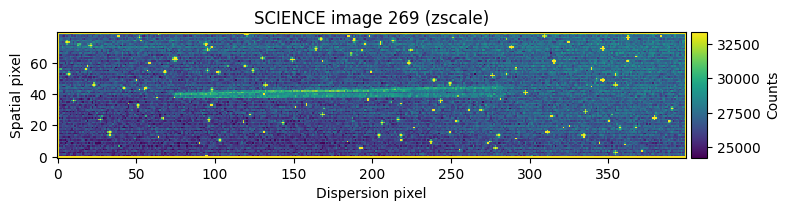

In [5]:
pandora.display_science_image(cube, image_index=269, scale_style="zscale", iraf_contrast=0.99)

## Routine from JWST-SOSS for converting Ramps to Slopes.  

In [6]:
fit_products_pre = pandora.compute_ramp_fit_products_r2s(
	ramp_cube,
	sigcut=2.0,
)

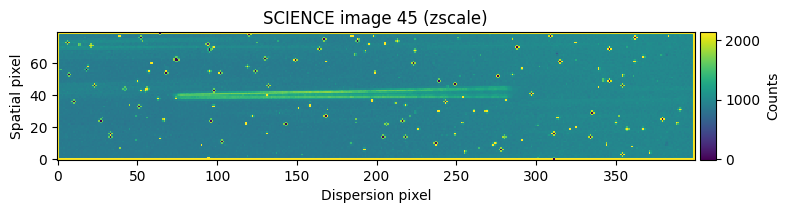

In [7]:
pandora.display_science_image(fit_products_pre["slope"], image_index=45, \
    scale_style="zscale", iraf_contrast=0.99)

## Identify hot-pixels.  

In [8]:
hot_pixel_mask, hot_info = pandora.detect_hot_pixels_from_ramp_fit(
	fit_products_pre["intercept"],
	scatter_cube=fit_products_pre["scatter"],
	intercept_sigma=8.0,
	min_intercept_offset_dn=150.0,
	scatter_sigma=8.0,
)

print(
	f"Hot pixels from ramp zero-point map: {hot_info['n_hot']} "
	f"({100.0 * hot_info['hot_fraction']:.4f}%)"
)

Hot pixels from ramp zero-point map: 1227 (3.8344%)


In [9]:
bad_clump_mask, bad_clump_info = pandora.detect_bad_pixel_clumps_from_ramp_fit(
	fit_products_pre["intercept"],
	fit_products_pre["slope"],
	scatter_cube=fit_products_pre["scatter"],
	min_intercept_offset_dn=badpix_params["min_intercept_offset_dn"],
	intercept_sigma=badpix_params["intercept_sigma"],
	slope_percentile=badpix_params["slope_percentile"],
	scatter_sigma=badpix_params["scatter_sigma"],
	dilate_iterations=badpix_params["core_dilate_iterations"],
)

print(
	f"Bad clump pixels from ramp diagnostics: {bad_clump_info['n_clump_pixels']} "
	f"({100.0 * bad_clump_info['clump_fraction']:.4f}%)"
)

Bad clump pixels from ramp diagnostics: 1184 (3.7000%)


In [10]:
# Expand clump cores by one pixel to capture bright residual wings around defects.
repair_mask = pandora.dilate_binary_mask(
	bad_clump_mask,
	iterations=badpix_params["wing_iterations"],
)
wing_only_mask = repair_mask & (~bad_clump_mask)
print(
	f"Expanded repair mask pixels (core+wings): {int(np.sum(repair_mask))} "
	f"({100.0 * np.mean(repair_mask):.4f}%)"
)

Expanded repair mask pixels (core+wings): 3339 (10.4344%)


Pixel status counts [0=good, 1=hot-only, 2=core, 3=wing]: {0: 28655, 1: 6, 2: 1184, 3: 2155}
Corrected pixel mask size: 3339 (10.4344%)


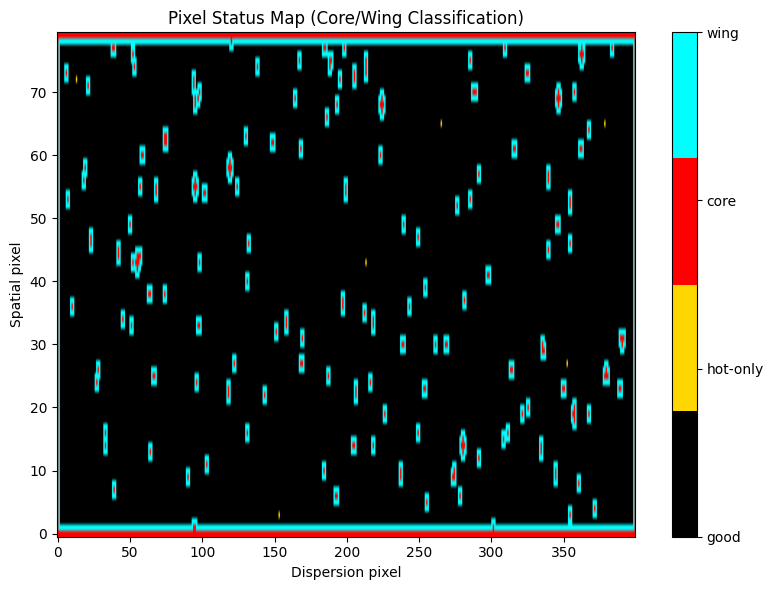

In [11]:
# Build user-facing pixel masks/maps for QA and downstream use.
corrected_pixel_mask = repair_mask.copy()
pixel_status_map = np.zeros(repair_mask.shape, dtype=np.uint8)
hot_only_mask = hot_pixel_mask & (~corrected_pixel_mask)
pixel_status_map[hot_only_mask] = 1
pixel_status_map[bad_clump_mask] = 2
pixel_status_map[wing_only_mask] = 3

print(
	"Pixel status counts [0=good, 1=hot-only, 2=core, 3=wing]:",
	{int(k): int(v) for k, v in zip(*np.unique(pixel_status_map, return_counts=True))},
)
print(
	f"Corrected pixel mask size: {int(np.sum(corrected_pixel_mask))} "
	f"({100.0 * np.mean(corrected_pixel_mask):.4f}%)"
)

# Quick-look map so corrected pixels are easy to inspect.
fig, ax = plt.subplots(figsize=(8, 6))
cmap = ListedColormap(["black", "gold", "red", "cyan"])
im = ax.imshow(np.rot90(pixel_status_map), origin="lower", cmap=cmap, vmin=0, vmax=3, aspect="auto")
ax.set_title("Pixel Status Map (Core/Wing Classification)")
ax.set_xlabel("Dispersion pixel")
ax.set_ylabel("Spatial pixel")
cb = fig.colorbar(im, ax=ax, ticks=[0, 1, 2, 3])
cb.ax.set_yticklabels(["good", "hot-only", "core", "wing"])
plt.tight_layout()
plt.show()

## Attempt to fix hot-pixels.  

In [12]:
slope_cube = fit_products_pre["slope"]
slope_cube_repaired, repair_info = pandora.correct_bad_pixels_with_neighbors(
	slope_cube,
	bad_mask=repair_mask,
	max_radius=badpix_params["repair_max_radius"],
	min_neighbors=badpix_params["repair_min_neighbors"],
	method=badpix_params["repair_method"],
	sigma_clip=badpix_params["repair_sigma_clip"],
)

print(
	f"Neighbor-repaired bad pixels in slope cube: {repair_info['n_fixed']} "
	f"({100.0 * repair_info['fixed_fraction']:.3f}% of masked samples)"
)

slope_cube_repaired, edge_info = pandora.correct_detector_edge_pixels(
	slope_cube_repaired,
	n_spatial_edge_rows=badpix_params["edge_n_spatial_rows"],
	spatial_low=badpix_params["edge_spatial_low"],
	spatial_high=badpix_params["edge_spatial_high"],
	dispersion_low=badpix_params["edge_dispersion_low"],
	dispersion_high=badpix_params["edge_dispersion_high"],
)

print(
	f"Edge correction applied: total={edge_info['n_replaced_total']} samples "
	f"(spatial-edge median={edge_info['n_replaced_spatial_median']}, dispersion-edge mean={edge_info['n_replaced_dispersion_mean']})"
)

Neighbor-repaired bad pixels in slope cube: 1472705 (99.562% of masked samples)
Edge correction applied: total=1134080 samples (spatial-edge median=1063200, dispersion-edge mean=70880)


## Dealing with Cosmic-Rays.  

Cosmic-ray correction applied: replaced 187530 samples (1.3229% of the cube)


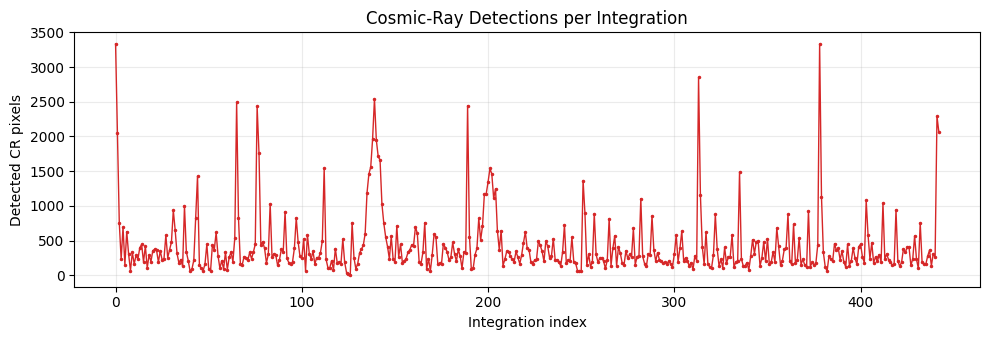

CR counts per integration: median=271.0, p95=1363.0, max=3334 at integration 0


In [13]:
slope_cube_cr_corrected, cr_mask, cr_info = pandora.correct_cosmic_rays_temporally(
	slope_cube_repaired,
	window_frames=cr_params["window_frames"],
	sigma=cr_params["sigma"],
	min_neighbors=cr_params["min_neighbors"],
	positive_only=cr_params["positive_only"],
)

print(
	f"Cosmic-ray correction applied: replaced {cr_info['n_replaced']} samples "
	f"({100.0 * cr_info['replacement_fraction']:.4f}% of the cube)"
)

if cr_params["plot_counts_vs_integration"]:
	cr_stats = pandora.plot_cosmic_ray_counts_by_integration(cr_mask)
	print(
		"CR counts per integration: "
		f"median={cr_stats['median']:.1f}, p95={cr_stats['p95']:.1f}, "
		f"max={cr_stats['max']} at integration {cr_stats['argmax']}"
	)

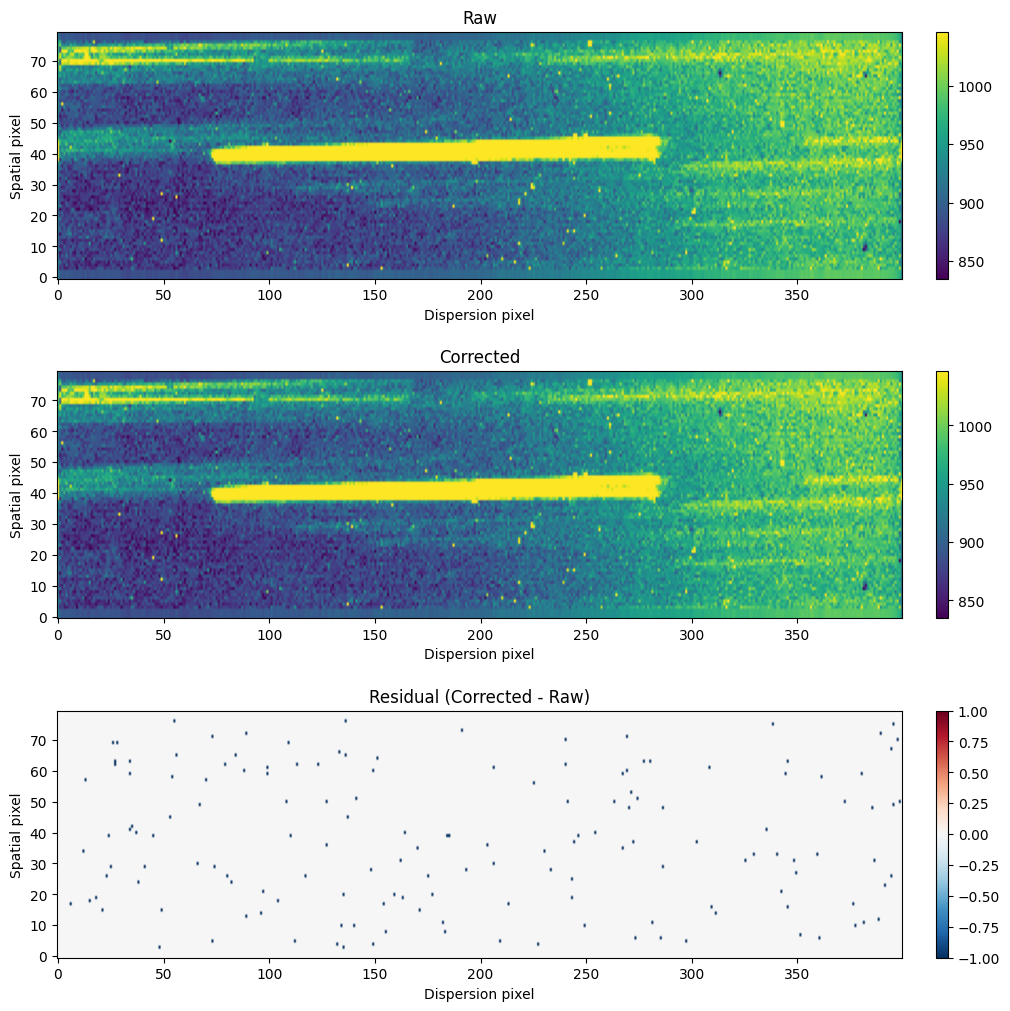

In [14]:
pandora.display_correction_comparison(
	slope_cube_repaired,
	slope_cube_cr_corrected,
	image_index=45,
	scale_style="zscale",
    iraf_contrast=0.1
)

## Aperture photometry settings and getting the trace (mostly done by eye)

Variable aperture bounds: left 37.0->33.0, right 43.0->41.0
Detected peak positions: [39]
Photometric aperture pixels: 1906


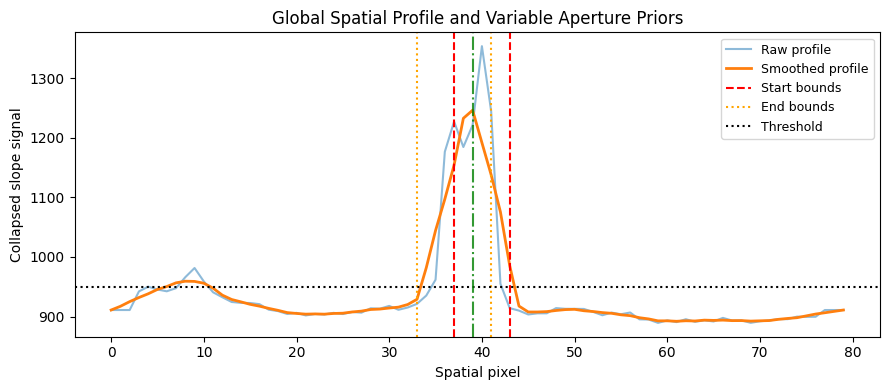

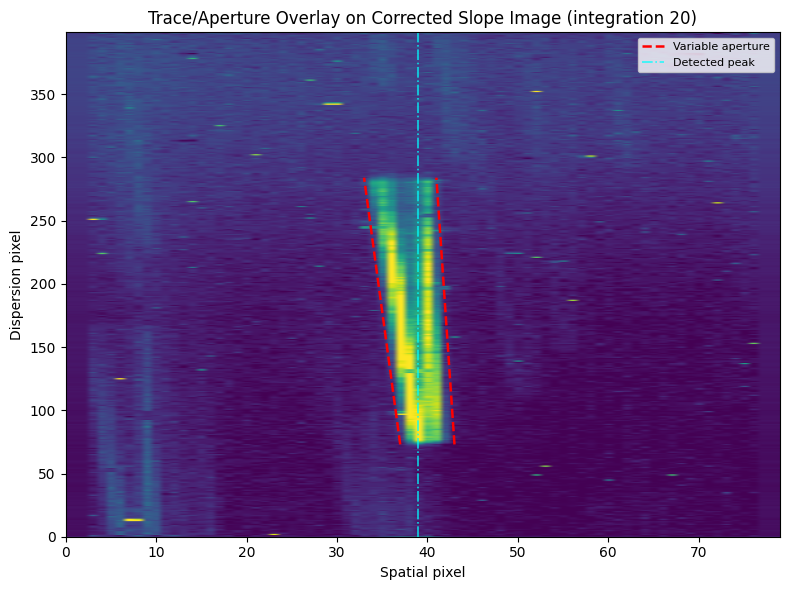

In [15]:
trace_est = pandora.estimate_trace_aperture(
	slope_cube_cr_corrected,
	dispersion_min=trace_params["dispersion_min"],
	dispersion_max=trace_params["dispersion_max"],
	expected_spatial_center=trace_params["expected_spatial_center"],
	max_half_width=trace_params["max_half_width"],
	smooth_window=trace_params["smooth_window"],
	threshold_sigma=trace_params["threshold_sigma"],
)

aperture_model = pandora.build_linear_trace_aperture(
	n_dispersion=trace_est["dispersion_pixels"].size,
	dispersion_min=trace_params["dispersion_min"],
	dispersion_max=trace_params["dispersion_max"],
	spatial_left_start=trace_params["spatial_left_start"],
	spatial_left_end=trace_params["spatial_left_end"],
	spatial_right_start=trace_params["spatial_right_start"],
	spatial_right_end=trace_params["spatial_right_end"],
	n_spatial=slope_cube_cr_corrected.shape[2],
)

print(
	"Variable aperture bounds: "
	f"left {trace_params['spatial_left_start']:.1f}->{trace_params['spatial_left_end']:.1f}, "
	f"right {trace_params['spatial_right_start']:.1f}->{trace_params['spatial_right_end']:.1f}"
)
print(f"Detected peak positions: {trace_est['peak_positions']}")
print(f"Photometric aperture pixels: {int(np.sum(aperture_model['aperture_mask']))}")

pandora.plot_spatial_profile(trace_est, trace_params)
pandora.plot_aperture_overlay(slope_cube_cr_corrected, aperture_model, trace_est)

## Get photometry.

Channel quality mask: 24 bad channels out of 212 (11.3%) at dispersion pixels: [73, 74, 75, 97, 98, 99, 130, 131, 132, 196, 197, 198, 242, 243, 244, 248, 249, 250, 253, 254, 255, 280, 281, 282]
Photometry bad-pixel mask: 3339 pixels flagged (10.4344%)


/home/rowe/python/pandora_rdf/pandora_funcs.py:1208: RuntimeWarning: All-NaN slice encountered
  median_spectrum = np.nanmedian(specs, axis=0)
/home/rowe/python/pandora_rdf/pandora_funcs.py:1267: RuntimeWarning: All-NaN slice encountered
  median_spectrum = np.nanmedian(extracted_spectra_masked, axis=0)
/home/rowe/python/pandora_rdf/.pandora_rdf/lib64/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


Observation gaps detected at integration indices: [64, 126, 188, 250, 312, 377]
Clean white-light: kept 390/443 integrations, excluded 53 excursions.
Extracted spectra shape: (443, 212)  (integration × dispersion)
White-light stats: median=2581.6, std=330.773
Pointing drift: dx rms=0.2832 pix, dy rms=1.3477 pix


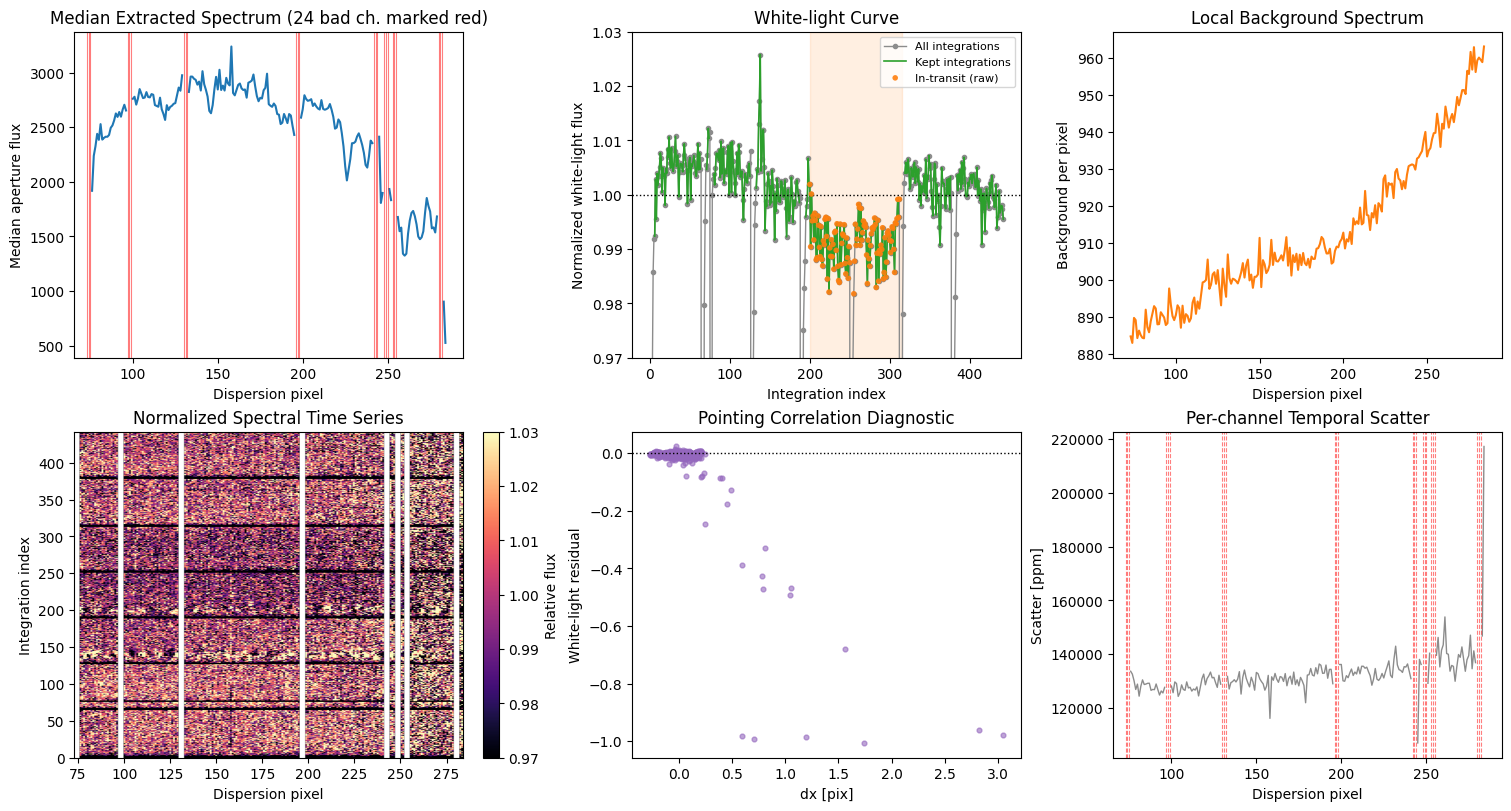

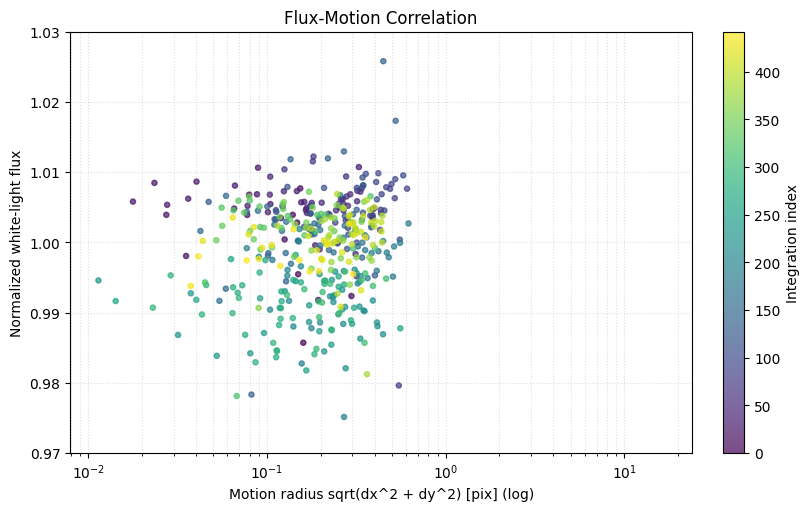

In [25]:
# Perform spectrophotometric extraction.
photometry_bad_mask = repair_mask

extracted_spectra, extracted_dispersion, extraction_info = pandora.extract_trace_spectra_variable_aperture(
	slope_cube_cr_corrected,
    aperture_model=aperture_model,
	bad_pixel_mask=photometry_bad_mask,
    subtract_background=extract_params["subtract_local_background"],
    background_inner_gap=extract_params["background_inner_gap"],
    background_width=extract_params["background_width"],
    background_mask=photometry_bad_mask,
    return_diagnostics=True,
)

channel_good = pandora.build_channel_quality_mask(aperture_model, photometry_bad_mask)
n_bad_channels = int(np.sum(~channel_good))
print(
    f"Channel quality mask: {n_bad_channels} bad channels out of "
    f"{channel_good.size} ({100.0 * n_bad_channels / channel_good.size:.1f}%) "
    f"at dispersion pixels: {extracted_dispersion[~channel_good].tolist()}"
)
print(
    f"Photometry bad-pixel mask: {int(np.sum(photometry_bad_mask))} pixels flagged "
    f"({100.0 * np.mean(photometry_bad_mask):.4f}%)"
)

extracted_spectra_masked = extracted_spectra.copy()
extracted_spectra_masked[:, ~channel_good] = np.nan

wl = pandora.compute_white_light_products(
    extracted_spectra_masked, extraction_info, exposure_time_s, nint, ngroup,
    transit_ingress_index=extract_params["transit_ingress_index"],
    transit_egress_index=extract_params["transit_egress_index"],
    use_wavelength_weights=extract_params["use_wavelength_weights"],
)
integration_time_axis = wl["integration_time_axis"]
time_axis_label      = wl["time_axis_label"]
oot_mask             = wl["oot_mask"]
white_light_norm     = wl["white_light_norm"]
median_spectrum      = wl["median_spectrum"]
normalized_spectra   = wl["normalized_spectra"]
spectral_scatter_ppm = wl["spectral_scatter_ppm"]
median_background_per_pixel = wl["median_background_per_pixel"]

centroid_info = pandora.compute_aperture_motion_centroids(
	slope_cube_cr_corrected, aperture_model,
    background_per_pixel=extraction_info["background_per_pixel"],
    bad_pixel_mask=photometry_bad_mask,
    guard_pixels=int(extract_params["motion_aperture_guard_pixels"]),
)
dx = centroid_info["spatial_centroid"]    - np.nanmedian(centroid_info["spatial_centroid"][oot_mask])
dy = centroid_info["dispersion_centroid"] - np.nanmedian(centroid_info["dispersion_centroid"][oot_mask])

integration_keep_mask = pandora.reject_photometric_excursions(
    white_light_norm, dx, dy, oot_mask,
    flux_window_low=extract_params["flux_window_low"],
    flux_window_high=extract_params["flux_window_high"],
    excursion_sigma=extract_params["excursion_sigma"],
    excursion_padding=extract_params["excursion_padding"],
    motion_sigma=extract_params["motion_sigma"],
)

# --- Gap / reacquisition masking ---
# Discard the first N integrations at the very start of the observation.
integration_keep_mask[:gap_params["initial_frames"]] = False

# Find time jumps that indicate an Earth-occultation or SAA gap.
_dt_s = np.diff(integration_jd) * 86400.0
_gap_starts = np.where(_dt_s > gap_params["gap_threshold_s"])[0]
print(f"Observation gaps detected at integration indices: {_gap_starts.tolist()}")
for _g in _gap_starts:
	_lo = int(_g) + 1
	_hi = min(nint, int(_g) + 1 + gap_params["reacq_frames"])
	integration_keep_mask[_lo:_hi] = False

if gap_params["manual_bad_indices"]:
	for _idx in gap_params["manual_bad_indices"]:
		if 0 <= int(_idx) < nint:
			integration_keep_mask[int(_idx)] = False
	print(f"Manual bad integrations excluded: {gap_params['manual_bad_indices']}")

white_light_clean = white_light_norm.copy()
white_light_clean[~integration_keep_mask] = np.nan

print(
    f"Clean white-light: kept {int(np.sum(integration_keep_mask))}/{integration_keep_mask.size} integrations, "
    f"excluded {int(np.sum(~integration_keep_mask))} excursions."
)
print(f"Extracted spectra shape: {extracted_spectra_masked.shape}  (integration × dispersion)")
print(f"White-light stats: median={np.nanmedian(wl['white_light']):.6g}, std={np.nanstd(wl['white_light']):.6g}")
print(f"Pointing drift: dx rms={np.nanstd(dx):.4f} pix, dy rms={np.nanstd(dy):.4f} pix")

pandora.plot_spectrophotometry_diagnostics(
    extracted_dispersion, median_spectrum, channel_good,
    integration_time_axis, white_light_norm, white_light_clean,
    median_background_per_pixel, normalized_spectra,
    dx, oot_mask, spectral_scatter_ppm, time_axis_label,
)
pandora.plot_flux_motion_correlation(dx, dy, white_light_norm, integration_time_axis, time_axis_label)

PCA: using 3 components from 13 telemetry channels.
OOT scatter before PCA detrending: 4292.3 ppm
OOT scatter  after PCA detrending: 3676.8 ppm


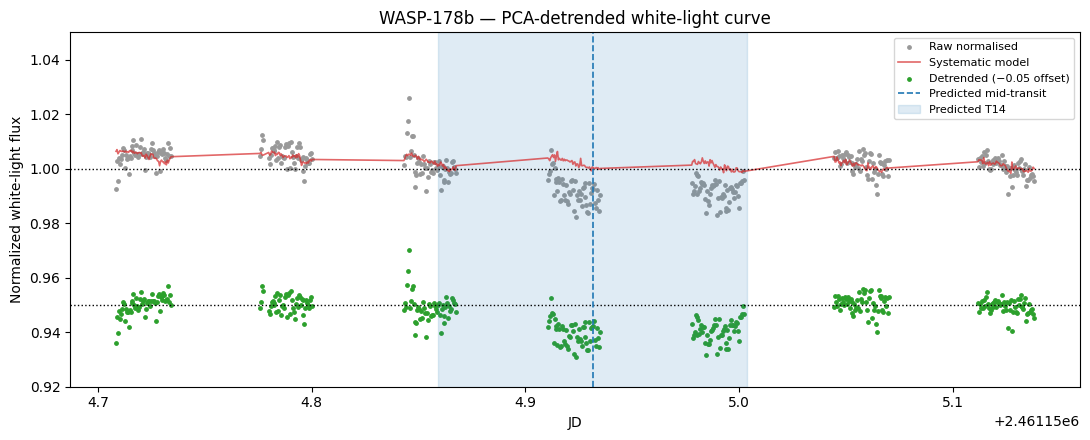

In [26]:
# --- PCA telemetry decorrelation ---
# Compute predicted event window from ephemeris (used in the plot below).
_epoch = int(np.rint((np.nanmedian(integration_jd) - ephem_params["t0_hjd_utc"]) / ephem_params["period_days"]))
event_center_jd   = ephem_params["t0_hjd_utc"] + _epoch * ephem_params["period_days"]
event_ingress_jd  = event_center_jd - 0.5 * ephem_params["t14_hours"] / 24.0
event_egress_jd   = event_center_jd + 0.5 * ephem_params["t14_hours"] / 24.0

# Build a telemetry matrix from the four spacecraft HDUs, standardise, and
# compute PCA components via SVD.  A linear systematic model is then fit
# OOT-only and removed from the full time series.
_tel_series = pandora.sample_fits_telemetry_to_integrations(
	fits_path,
	integration_jd,
	hdu_names=pca_params["telemetry_hdu_names"],
)

_tel_cols = []
for _k, _v in _tel_series.items():
	if np.all(np.isfinite(_v)) and np.nanstd(_v) > 0:
		_tel_cols.append((_v - np.nanmean(_v)) / np.nanstd(_v))

if len(_tel_cols) == 0:
	print("WARNING: No usable telemetry columns found for PCA decorrelation.")
	white_light_pca = white_light_clean.copy()
else:
	_tel_matrix = np.column_stack(_tel_cols)
	_u, _s_svd, _vh = np.linalg.svd(_tel_matrix, full_matrices=False)
	_n_comp = min(pca_params["n_components"], _u.shape[1])
	_pca_comps = _u[:, :_n_comp]
	print(f"PCA: using {_n_comp} components from {len(_tel_cols)} telemetry channels.")

	# Build design matrix for the kept integrations only.
	_valid = integration_keep_mask.copy()
	_t_rel = integration_jd - np.nanmedian(integration_jd[_valid])
	_bg_per_int = np.nanmedian(extraction_info["background_per_pixel"], axis=1)

	_poly_cols = [_t_rel ** p for p in range(pca_params["time_poly_order"] + 1)]
	_X_full = np.column_stack(_poly_cols + [dx, dy, _bg_per_int] + [_pca_comps[:, c] for c in range(_n_comp)])

	_X_oot = _X_full[_valid & oot_mask]
	_y_oot = white_light_norm[_valid & oot_mask]

	if _X_oot.shape[0] < _X_oot.shape[1] + 1:
		print("WARNING: Too few OOT integrations for PCA fit; skipping decorrelation.")
		white_light_pca = white_light_clean.copy()
	else:
		_c_pca, _, _, _ = np.linalg.lstsq(_X_oot, _y_oot, rcond=None)
		_baseline_full = _X_full @ _c_pca

		_wl_valid = white_light_norm[_valid]
		_base_valid = _baseline_full[_valid]
		_oot_valid = oot_mask[_valid]

		_detrended = _wl_valid / _base_valid
		_detrended /= np.nanmedian(_detrended[_oot_valid])

		white_light_pca = np.full(nint, np.nan)
		white_light_pca[_valid] = _detrended

		pca_oot_scatter_ppm = 1.0e6 * np.nanstd(_detrended[_oot_valid])
		raw_oot_scatter_ppm = 1.0e6 * np.nanstd(_wl_valid[_oot_valid])
		print(f"OOT scatter before PCA detrending: {raw_oot_scatter_ppm:.1f} ppm")
		print(f"OOT scatter  after PCA detrending: {pca_oot_scatter_ppm:.1f} ppm")

		# Diagnostic plot: raw + systematic model + detrended (offset -0.05).
		_t_plot = integration_jd[_valid]
		fig, ax = plt.subplots(figsize=(11, 4.5))
		ax.scatter(_t_plot, _wl_valid, color="0.6", s=6, label="Raw normalised")
		ax.plot(_t_plot, _base_valid, color="tab:red", lw=1.2, alpha=0.7, label="Systematic model")
		ax.scatter(_t_plot, _detrended - 0.05, color="tab:green", s=6, label="Detrended (−0.05 offset)")
		ax.axhline(1.0, color="k", ls=":", lw=1)
		ax.axhline(0.95, color="k", ls=":", lw=1)
		ax.axvline(event_center_jd, color="tab:blue", lw=1.2, ls="--", label="Predicted mid-transit")
		ax.axvspan(event_ingress_jd, event_egress_jd, color="tab:blue", alpha=0.14, label="Predicted T14")
		ax.set_xlabel("JD")
		ax.set_ylabel("Normalized white-light flux")
		ax.set_ylim(0.92, 1.05)
		ax.set_title("WASP-178b — PCA-detrended white-light curve")
		ax.legend(loc="best", fontsize=8)
		plt.tight_layout()
		plt.show()

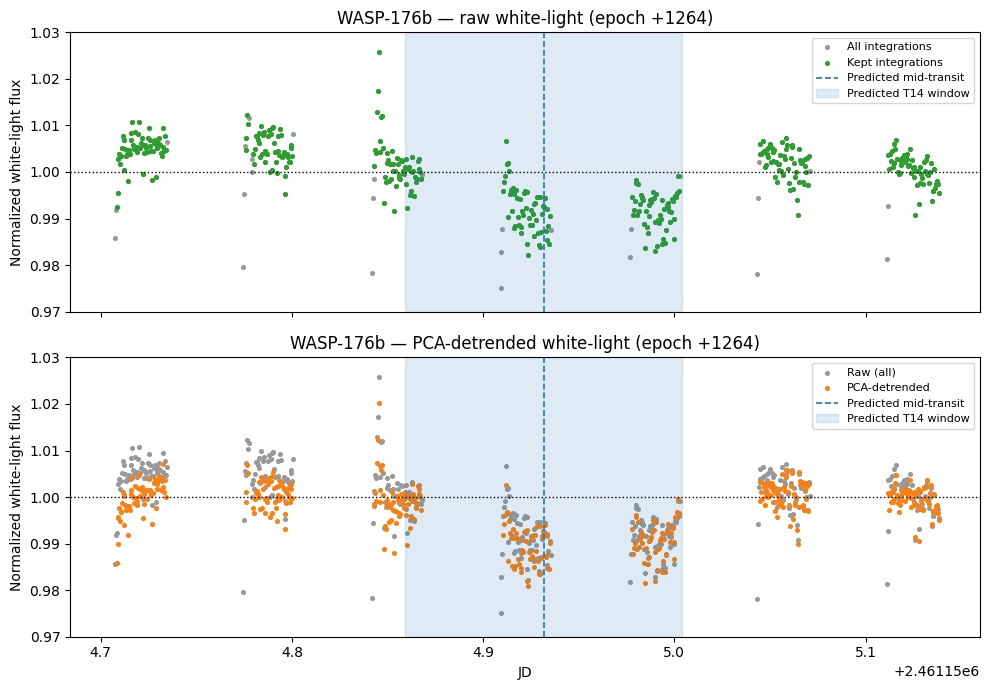

Predicted WASP-176b event in this time window: center JD=2461154.931614, ingress=2461154.859322, egress=2461155.003906


In [28]:
# Plot normalized white-light flux in JD with predicted WASP-176b event markers.
# event_center_jd / event_ingress_jd / event_egress_jd computed in PCA cell above.
epoch_nearest = _epoch

fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

ax0 = axes[0]
ax0.scatter(integration_jd, white_light_norm, color="0.6", label="All integrations", s=7)
ax0.scatter(integration_jd, white_light_clean, color="tab:green", label="Kept integrations", s=7)
ax0.axhline(1.0, color="k", ls=":", lw=1)
ax0.axvline(event_center_jd, color="tab:blue", lw=1.2, ls="--", label="Predicted mid-transit")
ax0.axvspan(event_ingress_jd, event_egress_jd, color="tab:blue", alpha=0.14, label="Predicted T14 window")
ax0.set_ylabel("Normalized white-light flux")
ax0.set_ylim(0.97, 1.03)
ax0.set_title(f"WASP-176b — raw white-light (epoch {epoch_nearest:+d})")
ax0.legend(loc="best", fontsize=8)

ax1 = axes[1]
ax1.scatter(integration_jd, white_light_norm, color="0.6", label="Raw (all)", s=7)
ax1.scatter(integration_jd, white_light_pca, color="tab:orange", label="PCA-detrended", s=7)
ax1.axhline(1.0, color="k", ls=":", lw=1)
ax1.axvline(event_center_jd, color="tab:blue", lw=1.2, ls="--", label="Predicted mid-transit")
ax1.axvspan(event_ingress_jd, event_egress_jd, color="tab:blue", alpha=0.14, label="Predicted T14 window")
ax1.set_xlabel("JD")
ax1.set_ylabel("Normalized white-light flux")
ax1.set_ylim(0.97, 1.03)
ax1.set_title(f"WASP-176b — PCA-detrended white-light (epoch {epoch_nearest:+d})")
ax1.legend(loc="best", fontsize=8)

plt.tight_layout()
plt.show()

print(
	f"Predicted WASP-176b event in this time window: center JD={event_center_jd:.6f}, "
	f"ingress={event_ingress_jd:.6f}, egress={event_egress_jd:.6f}"
)

## Experiments with difference imaging (this is kinda crappy at the moment)

In [17]:
# Difference-imaging motion settings.
diff_motion_params = {
	# Central-difference kernels for image gradients in x (columns) and y (rows).
	"kernel_dx": (-0.5, 0.0, 0.5),
	"kernel_dy": (-0.5, 0.0, 0.5),
	# Fit a variable background plane with offset + x + y terms.
	"background_order": 1,
	# Robust clip in units of MAD-sigma on the difference image residuals.
	"clip_sigma": 8.0,
	# Minimum valid pixels per frame required for a stable shift fit.
	"min_valid_pixels": 2500,
}

Difference-imaging fit quality: median valid pixels/frame=28537, median residual RMS=15.1981
Difference-imaging drift RMS: dx=0.1055 pix, dy=0.0185 pix
Correlation with aperture-centroid motion: corr(dx)=0.483, corr(dy)=0.131


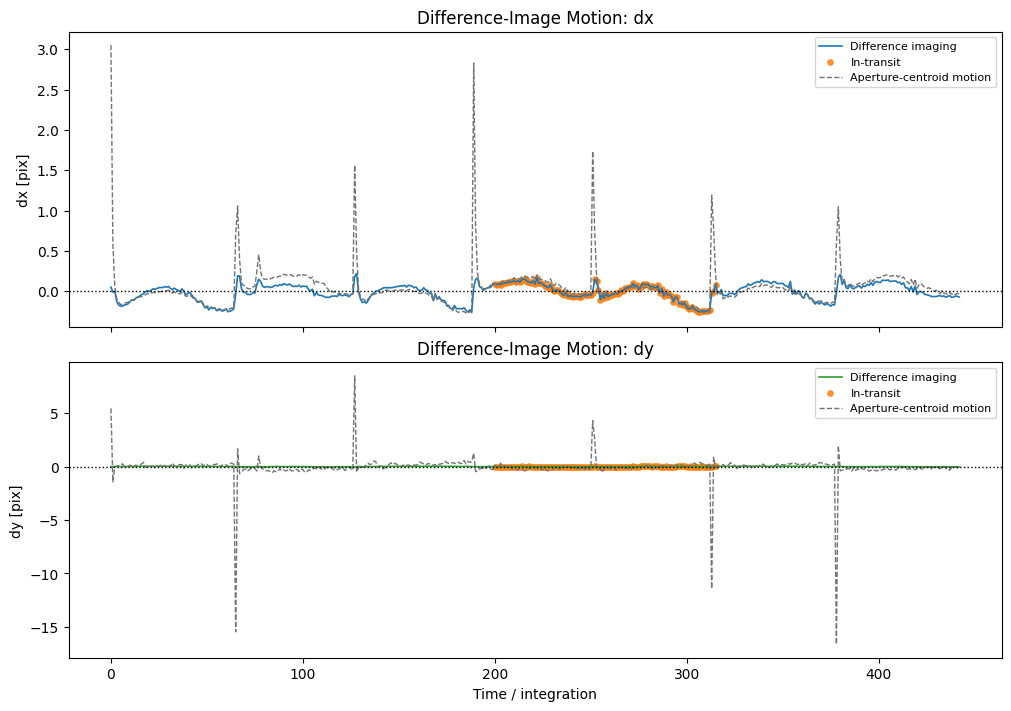

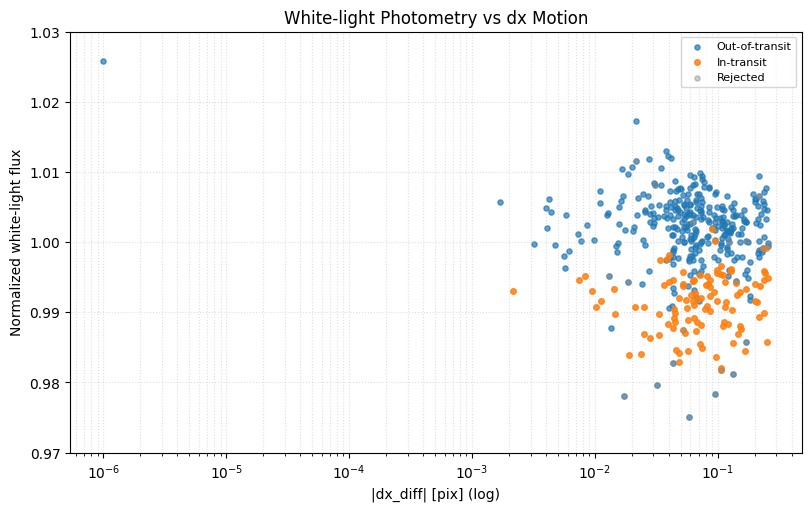

In [18]:
if np.any(oot_mask):
	rough_reference = np.nanmedian(slope_cube_cr_corrected[oot_mask], axis=0)
else:
	rough_reference = np.nanmedian(slope_cube_cr_corrected, axis=0)

diff_shift_init = pandora.estimate_difference_image_shifts(
	slope_cube_cr_corrected,
	reference_image=rough_reference,
	bad_pixel_mask=photometry_bad_mask,
	kernel_dx=diff_motion_params["kernel_dx"],
	kernel_dy=diff_motion_params["kernel_dy"],
	background_order=diff_motion_params["background_order"],
	clip_sigma=diff_motion_params["clip_sigma"],
	min_valid_pixels=diff_motion_params["min_valid_pixels"],
)

# Build aligned master frame from shifted OOT integrations.
diff_reference = pandora.build_aligned_master_frame(
	slope_cube_cr_corrected,
	diff_shift_init["dx"],
	diff_shift_init["dy"],
	use_mask=oot_mask,
)

# Pass 2: refined shifts against aligned master frame.
diff_shift = pandora.estimate_difference_image_shifts(
	slope_cube_cr_corrected,
	reference_image=diff_reference,
	bad_pixel_mask=photometry_bad_mask,
	kernel_dx=diff_motion_params["kernel_dx"],
	kernel_dy=diff_motion_params["kernel_dy"],
	background_order=diff_motion_params["background_order"],
	clip_sigma=diff_motion_params["clip_sigma"],
	min_valid_pixels=diff_motion_params["min_valid_pixels"],
)

dx_diff = diff_shift["dx"]
dy_diff = diff_shift["dy"]
dx_diff -= np.nanmedian(dx_diff[oot_mask])
dy_diff -= np.nanmedian(dy_diff[oot_mask])

valid_motion = np.isfinite(dx_diff) & np.isfinite(dy_diff)
valid_vs_centroid = valid_motion & np.isfinite(dx) & np.isfinite(dy)

print(
	"Difference-imaging fit quality: "
	f"median valid pixels/frame={np.nanmedian(diff_shift['n_valid_pixels']):.0f}, "
	f"median residual RMS={np.nanmedian(diff_shift['residual_rms']):.6g}"
)
print(
	"Difference-imaging drift RMS: "
	f"dx={np.nanstd(dx_diff[valid_motion]):.4f} pix, "
	f"dy={np.nanstd(dy_diff[valid_motion]):.4f} pix"
)
if np.any(valid_vs_centroid):
	corr_dx = np.corrcoef(dx_diff[valid_vs_centroid], dx[valid_vs_centroid])[0, 1]
	corr_dy = np.corrcoef(dy_diff[valid_vs_centroid], dy[valid_vs_centroid])[0, 1]
	print(f"Correlation with aperture-centroid motion: corr(dx)={corr_dx:.3f}, corr(dy)={corr_dy:.3f}")

pandora.plot_difference_imaging_motion(
	integration_time_axis,
	dx_diff,
	dy_diff,
	oot_mask=oot_mask,
	dx_reference=dx,
	dy_reference=dy,
)
pandora.plot_white_light_vs_dx_log(
	dx_diff,
	white_light_norm,
	oot_mask=oot_mask,
	integration_keep_mask=integration_keep_mask,
	dx_label="dx_diff",
)

In [19]:
diff_phot_params = {
	"subtract_background": True,
	"background_inner_gap": 2,
	"background_width": 10,
	"use_aperture_weights": True,
	"weight_sigma_scale": 4.0,
}

diagnostic_params = {
	"telemetry_hdu_names": ("VITL_DATA", "SC_QUATERNIONS", "SC_POSITION", "SC_VELOCITY"),
	"n_pca_components": 5,
	"max_plot_labels": 24,
}


Difference-image white-light stats: median=469842, std=60096.6
Difference-image normalized scatter (OOT): 123242.7 ppm


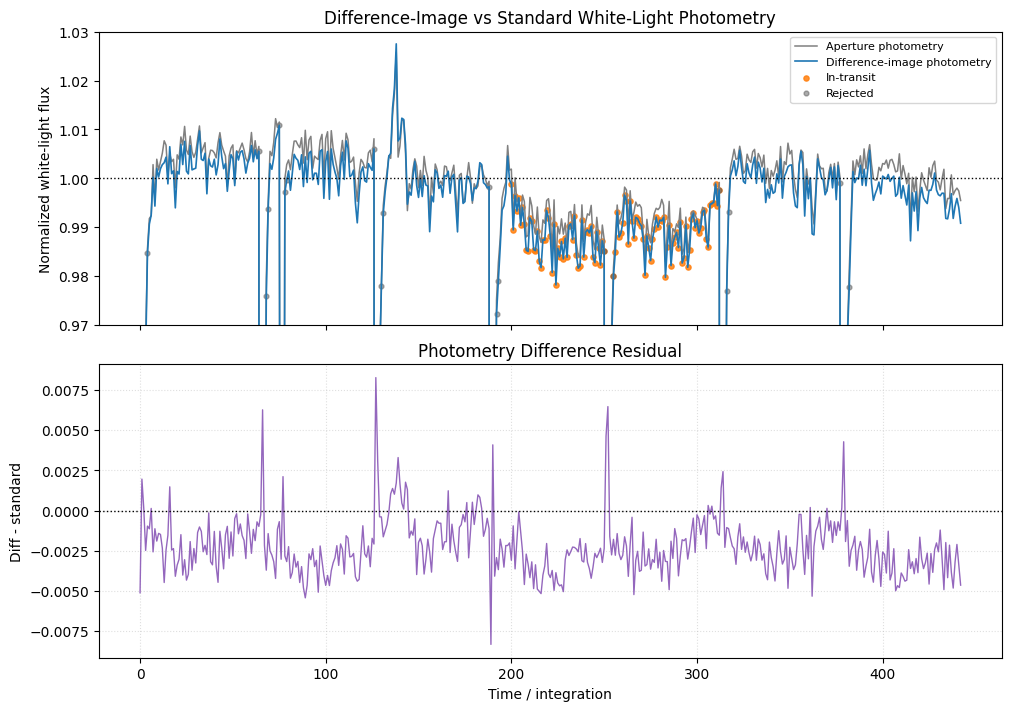

In [20]:
diff_spectra_total, diff_dispersion, diff_phot_info = pandora.extract_difference_image_photometry(
	slope_cube_cr_corrected,
	aperture_model,
	reference_image=diff_reference,
	shift_x=dx_diff,
	shift_y=dy_diff,
	bad_pixel_mask=photometry_bad_mask,
	subtract_background=diff_phot_params["subtract_background"],
	background_inner_gap=diff_phot_params["background_inner_gap"],
	background_width=diff_phot_params["background_width"],
	background_mask=photometry_bad_mask,
	use_aperture_weights=diff_phot_params["use_aperture_weights"],
	weight_sigma_scale=diff_phot_params["weight_sigma_scale"],
	return_diagnostics=True,
)

diff_spectra_masked = diff_spectra_total.copy()
diff_spectra_masked[:, ~channel_good] = np.nan

white_light_diff = np.nansum(diff_spectra_masked, axis=1)
white_light_diff_norm = white_light_diff / np.nanmedian(white_light_diff[oot_mask])

print(
	"Difference-image white-light stats: "
	f"median={np.nanmedian(white_light_diff):.6g}, std={np.nanstd(white_light_diff):.6g}"
)
print(
	"Difference-image normalized scatter (OOT): "
	f"{1e6*np.nanstd(white_light_diff_norm[oot_mask] - np.nanmedian(white_light_diff_norm[oot_mask])):.1f} ppm"
)

pandora.plot_difference_image_photometry_comparison(
	integration_time_axis,
	white_light_norm,
	white_light_diff_norm,
	oot_mask=oot_mask,
	integration_keep_mask=integration_keep_mask,
)

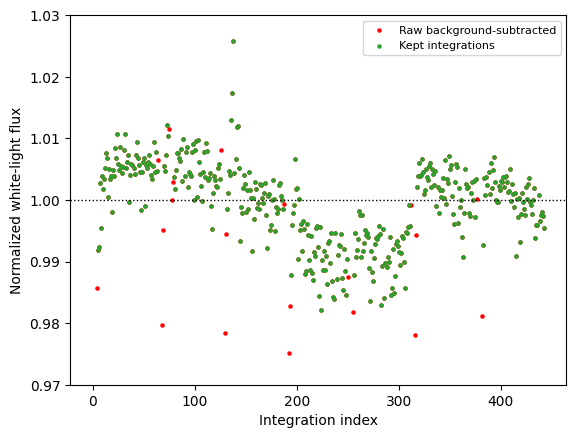

In [21]:
plt.scatter(integration_time_axis, white_light_norm, color="red", label="Raw background-subtracted", s=5)
plt.scatter(integration_time_axis, white_light_clean, color="tab:green", label="Kept integrations", s=5)
plt.axhline(1.0, color="k", ls=":", lw=1)
plt.xlabel(time_axis_label)
plt.ylabel("Normalized white-light flux")
plt.ylim(0.97, 1.03)
plt.legend(loc="best", fontsize=8)
plt.show()

Available table telemetry channels by HDU:
  VITL_DATA: ['jd', 'ra', 'dec', 'rot']
  SC_QUATERNIONS: ['jd', 'q0', 'q1', 'q2', 'q3']
  SC_POSITION: ['jd', 'p0', 'p1', 'p2']
  SC_VELOCITY: ['jd', 'v0', 'v1', 'v2']
Numeric RAW SCIENCE header cards: 10
Sampled telemetry channels onto integration grid: 13
Top |corr| with white_light_norm:
                 keep_mask:  nan
         white_light_clean:  1.0000
           white_light_raw:  1.0000
          white_light_norm:  1.0000
      white_light_diff_raw:  0.9498
     white_light_diff_norm:  0.9498
         SC_QUATERNIONS.q1: -0.2814
         SC_QUATERNIONS.q2: -0.2648
         SC_QUATERNIONS.q3: -0.2392
            SC_VELOCITY.v1: -0.2186
            SC_POSITION.p1: -0.2186
            SC_VELOCITY.v0:  0.2097


/home/rowe/python/pandora_rdf/.pandora_rdf/lib64/python3.13/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/rowe/python/pandora_rdf/.pandora_rdf/lib64/python3.13/site-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


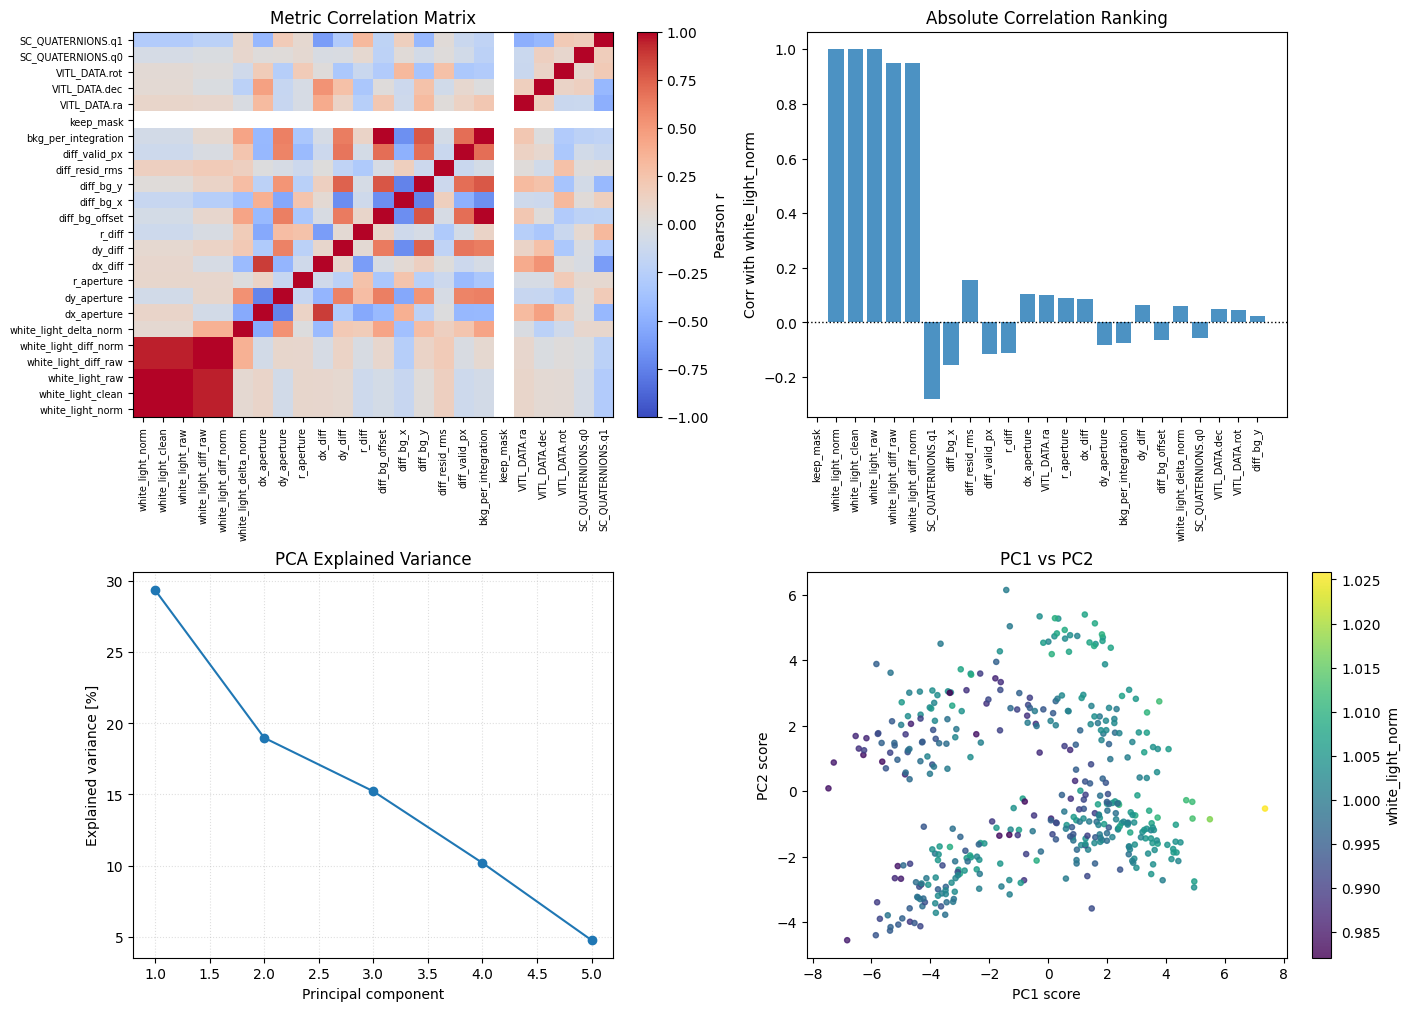

In [22]:
# Explore scatter drivers: photometry vs motion, fit residuals, and spacecraft telemetry.
integration_jd = np.asarray(time_jd_cube[:, -1], dtype=float)

telemetry_channels = pandora.list_fits_telemetry_channels(fits_path)
print("Available table telemetry channels by HDU:")
for hname, cols in telemetry_channels.items():
	print(f"  {hname}: {cols[:8]}{' ...' if len(cols) > 8 else ''}")

science_header_numeric = pandora.extract_numeric_header_cards(science_header)
print(f"Numeric RAW SCIENCE header cards: {len(science_header_numeric)}")

telemetry_series = pandora.sample_fits_telemetry_to_integrations(
	fits_path,
	integration_jd,
	hdu_names=diagnostic_params["telemetry_hdu_names"],
)
print(f"Sampled telemetry channels onto integration grid: {len(telemetry_series)}")

background_per_integration = np.nanmedian(extraction_info["background_per_pixel"], axis=1)
metric_series = {
	"white_light_norm": white_light_norm,
	"white_light_clean": white_light_clean,
	"white_light_raw": wl["white_light"],
	"white_light_diff_raw": white_light_diff,
	"white_light_diff_norm": white_light_diff_norm,
	"white_light_delta_norm": white_light_diff_norm - white_light_norm,
	"dx_aperture": dx,
	"dy_aperture": dy,
	"r_aperture": np.sqrt(dx * dx + dy * dy),
	"dx_diff": dx_diff,
	"dy_diff": dy_diff,
	"r_diff": np.sqrt(dx_diff * dx_diff + dy_diff * dy_diff),
	"diff_bg_offset": diff_shift["background_offset"],
	"diff_bg_x": diff_shift["background_x"],
	"diff_bg_y": diff_shift["background_y"],
	"diff_resid_rms": diff_shift["residual_rms"],
	"diff_valid_px": diff_shift["n_valid_pixels"].astype(float),
	"bkg_per_integration": background_per_integration,
	"keep_mask": integration_keep_mask.astype(float),
}
metric_series.update(telemetry_series)

metric_diag = pandora.compute_multimetric_correlation_and_pca(
	metric_series,
	white_key="white_light_norm",
	oot_mask=oot_mask,
	n_components=diagnostic_params["n_pca_components"],
)

print("Top |corr| with white_light_norm:")
keys = metric_diag["keys"]
corr_to_wl = metric_diag["corr_to_white"]
order = np.argsort(np.abs(corr_to_wl))[::-1]
for idx in order[:12]:
	print(f"  {keys[idx]:>24s}: {corr_to_wl[idx]: .4f}")

pandora.plot_multimetric_correlation_and_pca(
	metric_diag,
	white_light_norm=white_light_norm,
	max_labels=diagnostic_params["max_plot_labels"],
)

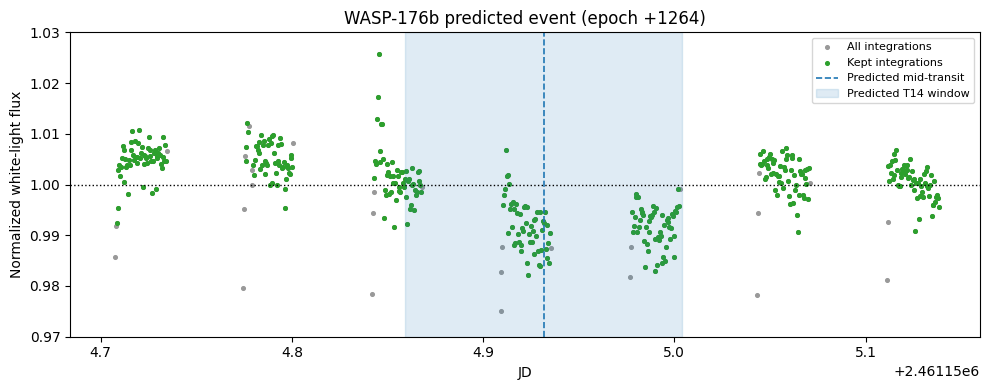

Predicted WASP-176b event in this time window: center JD=2461154.931614, ingress=2461154.859322, egress=2461155.003906


In [27]:
# Plot normalized white-light flux in JD with predicted WASP-176b event markers.
# event_center_jd / event_ingress_jd / event_egress_jd computed in PCA cell above.
epoch_nearest = _epoch

plt.figure(figsize=(10, 4))
plt.scatter(integration_jd, white_light_norm, color="0.6", label="All integrations", s=7)
plt.scatter(integration_jd, white_light_clean, color="tab:green", label="Kept integrations", s=7)
plt.axhline(1.0, color="k", ls=":", lw=1)
plt.axvline(event_center_jd, color="tab:blue", lw=1.2, ls="--", label="Predicted mid-transit")
plt.axvspan(event_ingress_jd, event_egress_jd, color="tab:blue", alpha=0.14, label="Predicted T14 window")
plt.xlabel("JD")
plt.ylabel("Normalized white-light flux")
plt.ylim(0.97, 1.03)
plt.title(f"WASP-176b predicted event (epoch {epoch_nearest:+d})")
plt.legend(loc="best", fontsize=8)
plt.tight_layout()
plt.show()

print(
	f"Predicted WASP-176b event in this time window: center JD={event_center_jd:.6f}, "
	f"ingress={event_ingress_jd:.6f}, egress={event_egress_jd:.6f}"
)

### Animations

Some routines for making animations.  Needs ffmpeg for saving as mp4.  The HTML render is quite RAM heavy, so I've leaf this out for now.

In [ ]:
anim = pandora.animate_datacube(
	slope_cube_cr_corrected,
	title="slope_cube_cr_corrected",
    scale_style="zscale",
    iraf_contrast=0.25,
    interval=80,          # ms per frame
)

from IPython.display import HTML
HTML(anim.to_jshtml())

pandora.animate_datacube(
	slope_cube_cr_corrected,
	title="slope_cube_cr_corrected",
	output_path="slope_cube_cr_corrected.mp4",
    fps=15,
    dpi=100,
)
